# Model Reference Adaptive Control (MRAC) meets Lyapunov

## 01. Motivation: The stability dilema
The **MIT Rule** has a problem regarding stability. This adaptation mechanism doesn't guarantee always convergence: If $\gamma$ is too high we can have oscilations during the adaptation and the system could become unstable. The instability stems from the **approximation error** in our sensitivity derivative. Recall that for the MIT rule, we assumed:
$$\frac{\partial e}{\partial K} \approx \frac{1}{s + a_m} [Signal]$$

This approximation is only valid if $K$ is constant. However, as $\gamma$ increases, $K$ changes rapidly. This creates a **coupling** between the parameter dynamics and the state dynamics. 

This problem derives from the fact we derived the law using the **Laplace transform**, which requires the system is **Linear Time-Invariant (LTI)**
By introducing the adaptive gain $K(t)$ into the feedback, the system automatically becomes **time-varying** 

The core property of the Laplace Transform that we use to solve ODEs is:
$$\mathcal{L}\{\dot{x}(t)\} = sX(s) - x(0)$$

But what happens when we try to transform a term where a parameter $K(t)$ multiplies a signal $r(t)$? 
In the time domain, multiplication of two time-varying signals transforms into **Convolution** in the frequency domain:
$$\mathcal{L}\{K(t) \cdot r(t)\} = K(s) * R(s) = \frac{1}{2\pi i} \int K(\sigma) R(s-\sigma) d\sigma$$

This is a mathematical nightmare!

To solve this we need to think in a new philosophy: **Lyapunov Stability**

## 02. Lyapunov Stability: Scalar case
Instead of looking for the roots of the system, we need to think in a more robust way.
Lyapunov tells us to look at the **Energy** of the system.

If you can prove that, no matter where you initialize the system, its **Total Energy is always decreasing** ($\dot{V} < 0$), then you don't need to know the exact path the internal variables take. You *know* for a mathematical fact it must eventually end up at the equilibrium point.

A valid Lyapunov function $V(x)$ must follow three strict rules:
1.  **$V(x) > 0$**: Energy must be positive if you aren't at the target i.e. $V(x) > 0 \quad \forall x \neq 0$.
2.  **$V(0) = 0$**: Energy is zero only at the equilibrium point $x=0$.
3.  **$\dot{V}(x) < 0$**: The system must be "dissipative." Energy must leave the system over time.

### Lyapunov adaptive law
Now, recalling our  **Parameter Error** $\tilde{K} = K - K^*$. Since $K^*$, our goal is to find an update rule for $K(t)$ that makes $\tilde{K}$ go toward whatever value is necessary to kill the tracking error.

Let's recall the our plant model:
$$\dot{x}(t) = A x(t) + B u(t)$$

Our reference model:
$$\dot{x_m}(t) =  A_m x_m(t) + B_m r(t)$$

And our control input:
$$u(t) = K_r(t) r(t) - K_x(t) x(t) $$

Based on your derivation, the evolution of this error is governed by:
$$\dot{e} = A_m e - B\tilde{K}_x x + B\tilde{K}_r r$$

We need to design $\dot{K}$ so that we ensure the tracking error converges to zero.

### Lyapunov candidate function
For that we define our Lyapunov candidate function function $V$. It must be positive if we have *any* tracking error or *any* gain error. We also include the unknown plant parameter $B$ (specifically its absolute value $|B|$) to help the math cancel out later:

$$V(e, \tilde{K}_x, \tilde{K}_r) = \frac{1}{2}e^2 + \frac{|B|}{2\gamma_x}\tilde{K}_x^2 + \frac{|B|}{2\gamma_r}\tilde{K}_r^2$$

* The **$\frac{1}{2}e^2$** term represents the "cost" of being away from the reference model.
* The **$\tilde{K}^2$** terms represent the "cost" of having the wrong gains.
* **$\gamma$** is our learning rate. Note that it's in the denominator: a larger $\gamma$ means the "energy cost" of parameter error is lower, allowing for faster movement.

Parks published a landmark paper titled *"Liapunov Redesign of Model Reference Adaptive Control Systems."*
We use the Parks Redesign (1966) structure. It follows a quadratic 'Energy' form because it mimics physical laws (like kinetic energy) and, more importantly, it simplifies the math so that the resulting adaptive law is a simple multiplication of error and state.

### Lyapunov derivative
To see if the system is stable, we take the time derivative $\dot{V}$. We want this to be $\leq 0$.
Using the chain rule:
$$\dot{V} = e\dot{e} + \frac{|B|}{\gamma_x}\tilde{K}_x\dot{\tilde{K}}_x + \frac{|B|}{\gamma_r}\tilde{K}_r\dot{\tilde{K}}_r$$

Now, substitute the expression for $\dot{e}$ from our tracking error dynamics:
$$\dot{V} = e(A_m e - B\tilde{K}_x x + B\tilde{K}_r r) + \frac{|B|}{\gamma_x}\tilde{K}_x\dot{K}_x + \frac{|B|}{\gamma_r}\tilde{K}_r\dot{K}_r$$

Distribute the $e$:
$$\dot{V} = A_m e^2 - Be\tilde{K}_x x + Be\tilde{K}_r r + \frac{|B|}{\gamma_x}\tilde{K}_x\dot{K}_x + \frac{|B|}{\gamma_r}\tilde{K}_r\dot{K}_r$$

We want $\dot{V} = A_m e^2$ (which is always negative because $A_m$ is Hurwitz). To achieve this, all the other terms must sum to zero. Let's group the terms by their parameter error:

$$\tilde{K}_x \left( -Bex + \frac{|B|}{\gamma_x}\dot{K}_x \right) + \tilde{K}_r \left( Ber + \frac{|B|}{\gamma_r}\dot{K}_r \right) = 0$$

For this to be true for any error, the terms inside the parentheses must be zero. Let's solve for $\dot{K}$ (assuming for our system that $B > 0$, so $B = |B|$, however if not we can define it from $\frac{B}{|B|} = \operatorname{sgn}(B)$):

**For the feedback gain ($K_x$):**
$$-ex + \frac{1}{\gamma_x}\dot{K}_x = 0 \implies \mathbf{\dot{K}_x = \operatorname{sgn}(B) \gamma_x e x}$$

**For the feedforward gain ($K_r$):**
$$er + \frac{1}{\gamma_r}\dot{K}_r = 0 \implies \mathbf{\dot{K}_r = -\operatorname{sgn}(B) \gamma_r e r}$$

We arived to the same adaption law from the MIT Rule, however they are not the same. The MIT Rule gave as result a filter that we simplified so that we can implement it easily in code, and they converged to the same update because we are in a 1st-order system.

## 03. Handling Uncertainty and Unknown Disturbances

So far, we assumed that the plant can be matched exactly by the reference model using the adaptive gains $K_x$ and $K_r$. That is an ideal case. In practice, real systems always contain uncertainty: friction, payload changes, aerodynamic effects, actuator mismatch, and external disturbances.

With the uncertain plant $\dot{x} = Ax + B[u + f(x)]$, the matching conditions can no longer be satisfied exactly. Even with perfect $K_x^*$ and $K_r^*$, the residual $f(x)$ will always drive the error away from zero. We need to actively estimate and cancel it.

where $f(x)$ is an unknown disturbance or uncertainty acting through the same channel as the control input. This is called a **matched uncertainty**, and it is the most favorable case for adaptive control because the controller can directly counteract it.

### Adding an adaptive disturbance compensator

The key assumption that makes everything tractable is **linear parameterizability**. We assume $f(x)$ can be expressed as a weighted sum of known basis functions:

$$f(x) = W^{*T}\Phi(x) + \epsilon(x)$$

where $W^* \in \mathbb{R}^n$ is an **unknown** ideal weight vector, $\Phi(x) \in \mathbb{R}^n$ is a vector of **known** basis functions we choose, and $\epsilon(x)$ is the residual approximation error (assumed small — often taken as zero for the ideal analysis).

We extend the control law with an adaptive approximation term:

$$
u(t)=K_r(t)r(t)-K_x(t)x(t)-W^T(t)\Phi(x)
$$

Here:

* $W$ is a vector of adaptive weights,
* $\Phi(x)$ is a vector of known basis functions,
* $W^T\Phi(x)$ is the controller’s estimate of the disturbance.

The idea is simple: instead of trying to learn the exact physics of the disturbance, we learn a function that is “good enough” to cancel most of its effect on the tracking error.

The basis functions $\Phi(x)$ are the design choice. Common examples:

| Type | Form | Good for |
|---|---|---|
| Polynomial | $[1, x, x^2, x^3, \ldots]^T$ | Smooth, bounded dynamics |
| Radial Basis (RBF) | $[e^{-\|x-c_1\|^2/\sigma^2}, \ldots]^T$ | Localized nonlinearities |
| Fourier | $[\sin(\omega_1 x), \cos(\omega_1 x), \ldots]^T$ | Periodic disturbances |
| Neural Network | $[\sigma(w_1^T x + b_1), \ldots]^T$ | General approximation |

The critical point: $\Phi(x)$ must be chosen by the designer based on knowledge of what *type* of nonlinearity $f(x)$ is, even if its magnitude (i.e. $W^*$) is unknown.

Substituting $u = K_r r - K_x x - W^T\Phi(x)$ into the uncertain plant:

$$
\dot{e}=A_me-B\tilde{K}_x x+B\tilde{K}_r r-B\tilde{W}^T\Phi(x)+B\varepsilon(x,t)
$$

with $\tilde{W}=W-W^*$

This is the key point: the adaptive law can cancel the terms related to parameter error, but the residual approximation error $\varepsilon(x,t)$ will still remain.

### Lyapunov function with disturbance adaptation

We now extend the Lyapunov candidate to include the uncertainty weights:

$$ V(e,\tilde{K}_x,\tilde{K}_r,\tilde{W}) =
\frac{1}{2}e^2
+
\frac{|B|}{2\gamma_x}\tilde{K}_x^2
+
\frac{|B|}{2\gamma_r}\tilde{K}_r^2
+
\frac{|B|}{2\gamma_w}\tilde{W}^T\tilde{W}
$$

This function measures the combined “energy” of:

* the tracking error $e$,
* the gain estimation errors $\tilde{K}_x$ and $\tilde{K}_r$,
* the uncertainty estimation error $\tilde W$.

Its time derivative is

$$
\dot V =
e\dot e
+
\frac{|B|}{\gamma_x}\tilde K_x \dot{\tilde K}_x
+
\frac{|B|}{\gamma_r}\tilde K_r \dot{\tilde K}_r
+
\frac{|B|}{\gamma_w}\tilde W^T \dot{\tilde W}
$$

Substituting the error dynamics gives terms that can be canceled by choosing the adaptive laws as

$$
\dot K_x = \operatorname{sgn}(B)\gamma_x ex
$$

$$
\dot K_r = -\operatorname{sgn}(B)\gamma_r er
$$

$$
\dot W = \operatorname{sgn}(B)\gamma_w e\Phi(x)
$$

With these updates, the Lyapunov derivative reduces to a negative definite term plus a residual term caused by the approximation error:

$$
\dot V \le A_m e^2 + eB\varepsilon(x,t)
$$

So, if $\varepsilon(x,t)=0$, the tracking error can converge asymptotically to zero. If $\varepsilon(x,t)\neq 0$, then the error is generally **uniformly ultimately bounded**, meaning it remains bounded and can be made small by improving the basis functions or adding robustness.

## 04. Hands on - Python implementation

Recalling our nominal plant:
$$\dot{v} = -\frac{c_b}{m}v + \frac{1}{m}u$$

In standard form 
$$\dot{v} = av + b [u + f(v, t)]$$
with $a =-\frac{c_b}{m}$ and $b = \frac{1}{m}$ are unknown parameters.

For illustration purpuses, let's suppose we have the following disturbance
$$
f(v, t) = \theta_1 v(t)^2 + \theta_2 sin(v(t))
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reference model parameters
a_m = -0.5
b_m = 0.5

# Actual plant parameters
c_b = 50
m = 1500

# Diturbance Model
theta = [0.1, -40]

def f_real(v, theta, t):
    # Note here we don't use t, but keep it as placeholder for future
    return  theta[0] * v**2 + theta[1] * np.sin(v/(2*np.pi))

### Case 1: Perfect disturbance representation
$$
\Phi(v) = \begin{bmatrix} v^2 \ \sin(v) \end{bmatrix}
$$
* ideal case: $W^* = [\theta_1, \theta_2]^T$

In [2]:
disturbance_time = 30

def Phi(v):
    return np.array([v**2, np.sin(v/(2*np.pi))])

def run_simulation_dist(use_dist_model=True):
    dt, T = 0.01, 60
    time = np.arange(0, T, dt)
    
    # Initial car parameters
    m, c_b = 1500.0, 50.0
    
    # Initialize States and Gains
    v, v_m = 0.0, 0.0
    Kr, Kx = 0.0, 0.0
    Kw = np.zeros(2)
    gamma = [0.1, 0.1, 0.01]
    
    hist = {'v': [], 'vm': [], 'error': [], 'Kw1': [], 'Kw2': [], 'u':[], 'd':[]}
    
    for t in time:
        r = 30.0 if t > 5.0 else 0.0
        
        # Scenario change: Massive disturbance at 30s
        if t > disturbance_time:
            m = 5000.0   # 5x heavier
            c_b = 100.0  # Higher friction
            
        # Control Law
        # u = Kr*r - Kx*v - W^T\Phi(x)
        dist_estimation = Phi(v)
        dist_correction = np.dot(Kw, dist_estimation) if use_dist_model else 0.0
        u = Kr * r - Kx * v - dist_correction
        
        # Reference model dynamics
        dvm_dt = a_m * v_m + b_m * r
        v_m += dvm_dt * dt
        
        # Plant Dynamics
        dist =  f_real(v, theta, t)
        dv_dt = -(c_b/m) * v + (1/m) * (u + dist)
        v += dv_dt * dt
        
        # Error and Adaptation
        error = v - v_m
        dKr_dt = -gamma[0] * error * r
        dKx_dt =  gamma[1] * error * v
        dKw_dt =  gamma[2] * error * dist_estimation

        Kr += dKr_dt * dt
        Kx += dKx_dt * dt
        if use_dist_model:
            Kw += dKw_dt * dt
            
        hist['v'].append(v)
        hist['vm'].append(v_m)
        hist['error'].append(error)
        hist['Kw1'].append(Kw[0])
        hist['Kw2'].append(Kw[1])
        hist['u'].append(u)
        hist['d'].append(dist)
        
    return time, hist
    
t, hist_vanilla = run_simulation_dist(use_dist_model=False)
t, hist_disturbance = run_simulation_dist(use_dist_model=True)

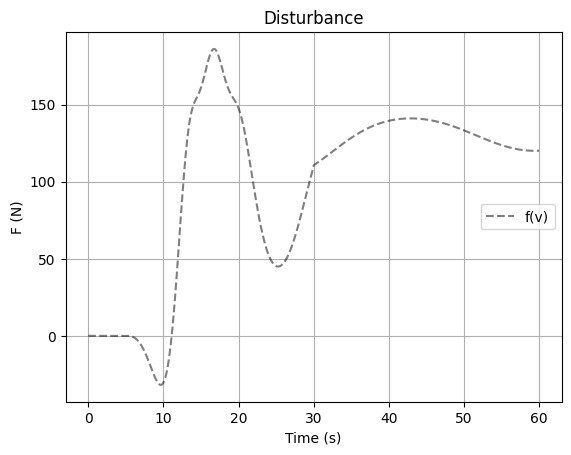

In [3]:
plt.plot(t, hist_vanilla['d'], 'k--', label='f(v)', alpha=0.5)
plt.title('Disturbance')
plt.ylabel('F (N)')
plt.legend(loc=7)
plt.xlabel('Time (s)')
plt.grid()

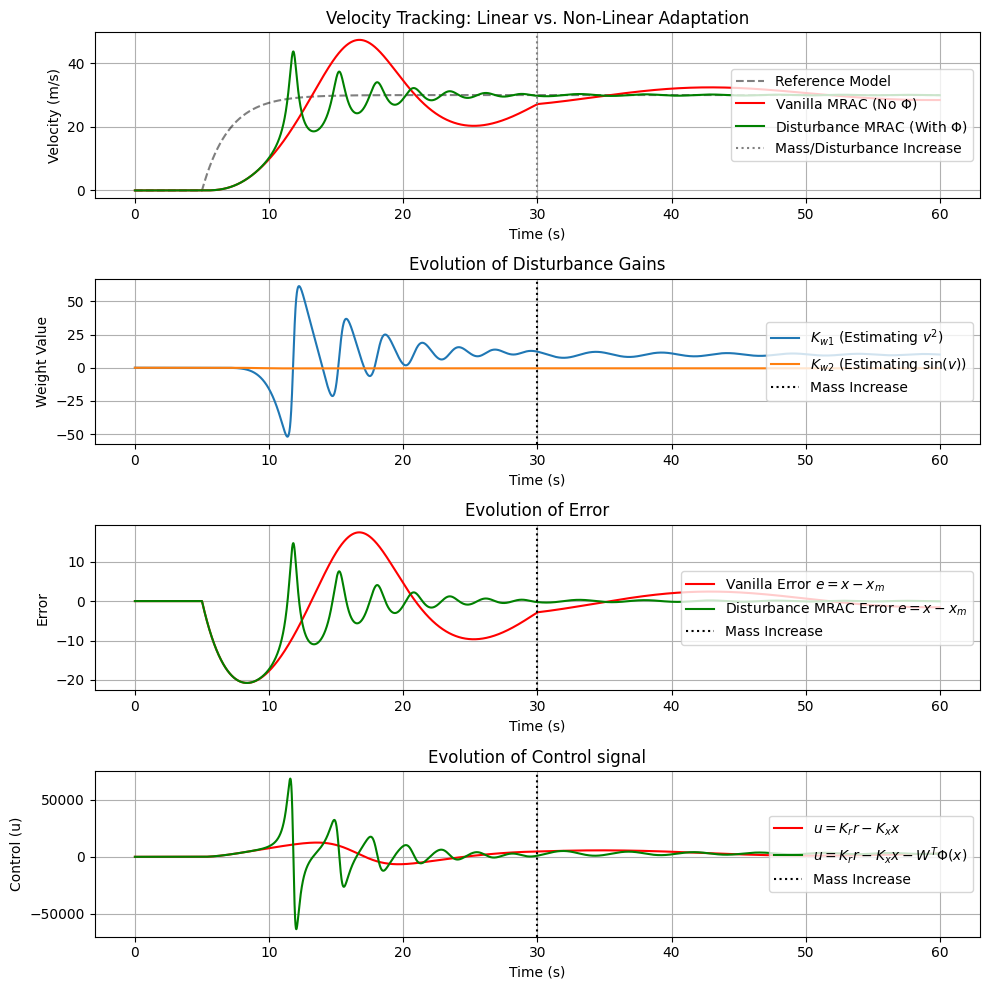

In [4]:
plt.figure(figsize=(10, 10))

plt.subplot(4, 1, 1)
plt.plot(t, hist_vanilla['vm'], 'k--', label='Reference Model', alpha=0.5)
plt.plot(t, hist_vanilla['v'], 'r', label='Vanilla MRAC (No $\Phi$)')
plt.plot(t, hist_disturbance['v'], 'g', label='Disturbance MRAC (With $\Phi$)')
plt.axvline(x=disturbance_time, color='gray', linestyle=':', label='Mass/Disturbance Increase')
plt.title('Velocity Tracking: Linear vs. Non-Linear Adaptation')
plt.ylabel('Velocity (m/s)')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(t, hist_disturbance['Kw1'], label='$K_{w1}$ (Estimating $v^2$)')
plt.plot(t, hist_disturbance['Kw2'], label='$K_{w2}$ (Estimating $\sin(v)$)')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title('Evolution of Disturbance Gains')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(4, 1, 3)
plt.plot(t, hist_vanilla['error'], 'r', label='Vanilla Error $e = x - x_m$')
plt.plot(t, hist_disturbance['error'], 'g',  label='Disturbance MRAC Error $e = x - x_m$')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title('Evolution of Error')
plt.ylabel('Error')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(t, hist_vanilla['u'], 'r', label='$u=K_r r - K_x x$')
plt.plot(t, hist_disturbance['u'], 'g', label='$u=K_r r - K_x x - W^T\Phi(x)$')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title('Evolution of Control signal')
plt.ylabel('Control (u)')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.tight_layout()
plt.show()

In [5]:
# Comparison estimation weights
print(f"Estimating $v^2$ -  Real: {theta[0]}, Adaption: {hist_disturbance['Kw1'][-1]}")
print(f"Estimating $\sin(v)$ - Real: {theta[1]}, Adaption: {hist_disturbance['Kw2'][-1]}")

Estimating $v^2$ -  Real: 0.1, Adaption: 9.95606125452496
Estimating $\sin(v)$ - Real: -40, Adaption: -0.4105772425762837


### Case 2: Under/over-parametrized disturbance representation
$$
\Phi_{under}(v) = \begin{bmatrix} v^2 \end{bmatrix}
$$

$$
\Phi_{perfect}(v) = \begin{bmatrix} v^2 \ sin(v) \end{bmatrix}
$$

$$
\Phi_{over}(v) = \begin{bmatrix} v^2 \ sin(v) \ v \end{bmatrix}
$$

$$
\Phi_{overwrongmodel}(v) = \begin{bmatrix} v \ \sqrt{|v|} \ 1 \end{bmatrix}
$$

In [6]:
disturbance_time = 30

def run_simulation_phi(Phi, gamma, f_real=f_real):
    dt, T = 0.01, 60
    time = np.arange(0, T, dt)
    
    # Initial car parameters
    m, c_b = 1500.0, 50.0
    
    # Initialize States and Gains
    v, v_m = 0.0, 0.0
    Kr, Kx = 0.0, 0.0
    Kw = np.zeros(len(Phi(0)))
    
    hist = {'v': [], 'vm': [], 'error': [], 'Kr': [], 'Kx': [], 'u':[], 'd':[], 'r':[]}
    for i in range(len(Kw)):
        hist[f'Kw{i+1}']=[]
    
    for t in time:
        r = 30.0 if t > 5.0 else 0.0
        
        # Scenario change: Massive disturbance at 30s
        if t > disturbance_time:
            m = 5000.0   # 5x heavier
            c_b = 100.0  # Higher friction
            
        # Control Law
        # u = Kr*r - Kx*v - W^T\Phi(x)
        dist_estimation = Phi(v)
        dist_correction = np.dot(Kw, dist_estimation)
        u = Kr * r - Kx * v - dist_correction
        
        # Reference model dynamics
        dvm_dt = a_m * v_m + b_m * r
        v_m += dvm_dt * dt
        
        # Plant Dynamics
        dist =  f_real(v, theta, t)
        dv_dt = -(c_b/m) * v + (1/m) * (u + dist)
        v += dv_dt * dt
        
        # Error and Adaptation
        error = v - v_m
        dKr_dt = -gamma[0] * error * r
        dKx_dt =  gamma[1] * error * v
        dKw_dt =  gamma[2] * error * dist_estimation

        Kr += dKr_dt * dt
        Kx += dKx_dt * dt
        Kw += dKw_dt * dt
            
        hist['v'].append(v)
        hist['vm'].append(v_m)
        hist['error'].append(error)
        hist['Kr'].append(Kr)
        hist['Kx'].append(Kx)
        for i in range(len(Kw)):
            hist[f'Kw{i+1}'].append(Kw[i])  
        hist['u'].append(u)
        hist['d'].append(dist)
        hist['r'].append(r)
        
    return time, hist

def Phi_under(v):
    return np.array([np.sin(v/(2*np.pi))])

def Phi_over(v):
    return np.array([v**2,  np.sin(v/(2*np.pi)), v])

def Phi_over_wrong_model(v):
    return np.array([1, np.sqrt(np.abs(v)), v])

def Phi(v):
    return np.array([v**2, np.sin(v/(2*np.pi))])

gamma = [0.1, 0.1, 0.1]  # Exagerated to evidence the difference

t, hist = run_simulation_phi(Phi, gamma=gamma)
t, hist_under = run_simulation_phi(Phi_under, gamma=gamma)
t, hist_over = run_simulation_phi(Phi_over, gamma=gamma)
t, hist_over_wrong_model = run_simulation_phi(Phi_over_wrong_model, gamma=gamma)

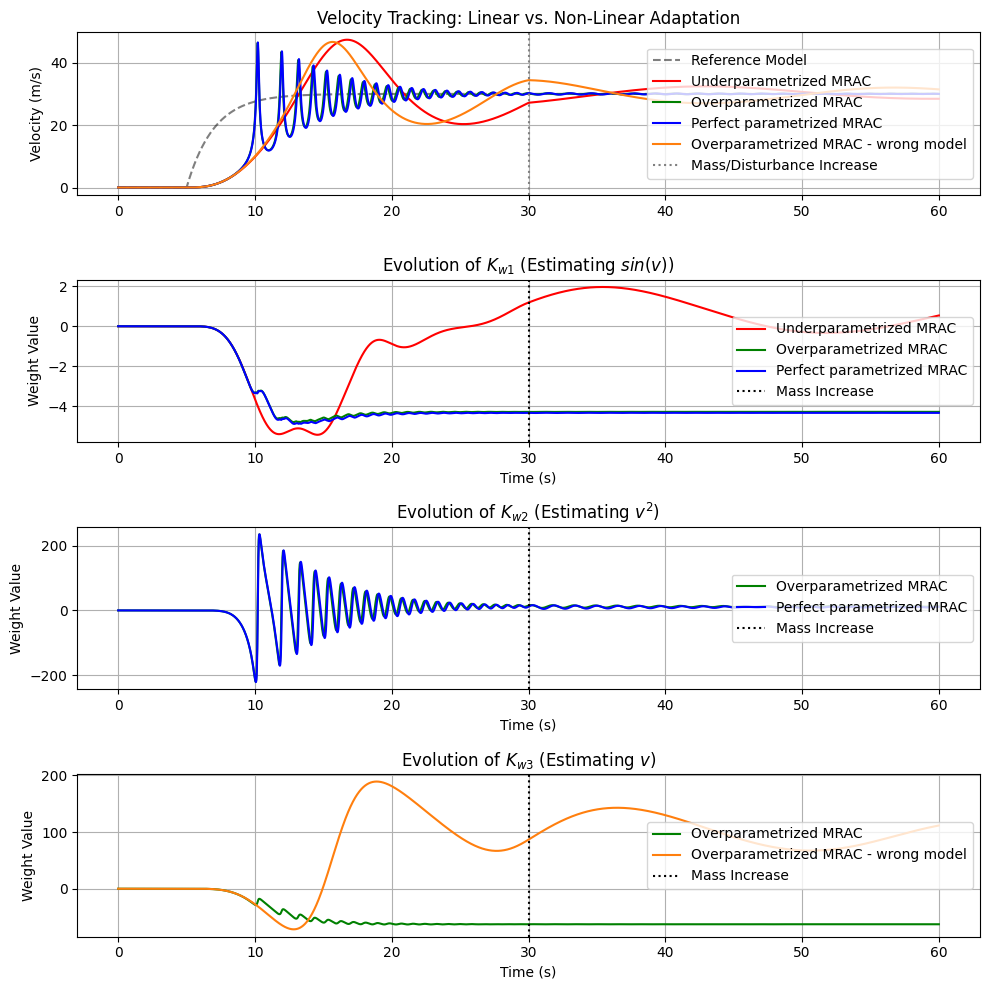

In [7]:
plt.figure(figsize=(10, 10))

plt.subplot(4, 1, 1)
plt.plot(t, hist['vm'], 'k--', label='Reference Model', alpha=0.5)
plt.plot(t, hist_under['v'], 'r', label='Underparametrized MRAC')
plt.plot(t, hist_over['v'], 'g', label='Overparametrized MRAC')
plt.plot(t, hist['v'], 'b', label='Perfect parametrized MRAC')
plt.plot(t, hist_over_wrong_model['v'], 'tab:orange', label='Overparametrized MRAC - wrong model')
plt.axvline(x=disturbance_time, color='gray', linestyle=':', label='Mass/Disturbance Increase')
plt.title('Velocity Tracking: Linear vs. Non-Linear Adaptation')
plt.ylabel('Velocity (m/s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(t, hist_under['Kw1'], 'r', label='Underparametrized MRAC')
plt.plot(t, hist_over['Kw2'], 'g', label='Overparametrized MRAC')
plt.plot(t, hist['Kw2'], 'b', label='Perfect parametrized MRAC')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title('Evolution of $K_{w1}$ (Estimating $sin(v)$)')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(4, 1, 3)
plt.plot(t, hist_over['Kw1'], 'g', label='Overparametrized MRAC')
plt.plot(t, hist['Kw1'], 'b', label='Perfect parametrized MRAC')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title('Evolution of $K_{w2}$ (Estimating $v^2$)')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(t, hist_over['Kw3'], 'g', label='Overparametrized MRAC')
plt.plot(t, hist_over_wrong_model['Kw3'], 'tab:orange', label='Overparametrized MRAC - wrong model')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title('Evolution of $K_{w3}$ (Estimating $v$)')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.tight_layout()
plt.show()

#### Parameter drift
Weights keep growing/oscillating trying to cancel impossible dynamics

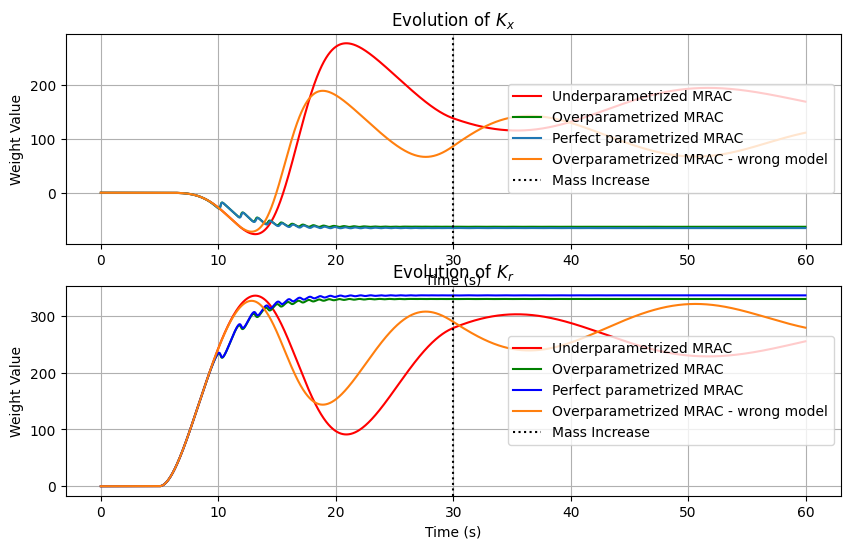

In [8]:
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, hist_under['Kx'], 'r', label='Underparametrized MRAC')
plt.plot(t, hist_over['Kx'], 'g', label='Overparametrized MRAC')
plt.plot(t, hist['Kx'], label='Perfect parametrized MRAC')
plt.plot(t, hist_over_wrong_model['Kx'], 'tab:orange', label='Overparametrized MRAC - wrong model')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title('Evolution of $K_x$')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t, hist_under['Kr'], 'r', label='Underparametrized MRAC')
plt.plot(t, hist_over['Kr'], 'g', label='Overparametrized MRAC')
plt.plot(t, hist['Kr'], 'b', label='Perfect parametrized MRAC')
plt.plot(t, hist_over_wrong_model['Kr'], 'tab:orange', label='Overparametrized MRAC - wrong model')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title('Evolution of $K_r$')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

In [9]:
# Comparison estimation weights
print("Underparametrized")
print(f"Estimating $\sin(v)$ -  Real: {theta[1]}, Adaption: {hist_under['Kw1'][-1]}")

print("\nPerfect parametrized")
print(f"Estimating $v^2$ -  Real: {theta[0]}, Adaption: {hist['Kw1'][-1]}")
print(f"Estimating $\sin(v)$ - Real: {theta[1]}, Adaption: {hist['Kw2'][-1]}")

print("\nOver parametrized")
print(f"Estimating $v^2$ -  Real: {theta[0]}, Adaption: {hist_over['Kw1'][-1]}")
print(f"Estimating $\sin(v)$ - Real: {theta[1]}, Adaption: {hist_over['Kw2'][-1]}")
print(f"Estimating $v$ - Real: {0}, Adaption: {hist_over['Kw3'][-1]}")

print("\nOver parametrized Wrong model")
print(f"Estimating bias -  Real: {0}, Adaption: {hist_over_wrong_model['Kw1'][-1]}")
print(f"Estimating $\sqrt(v)$ - Real: {0}, Adaption: {hist_over_wrong_model['Kw2'][-1]}")
print(f"Estimating $v$ - Real: {0}, Adaption: {hist_over_wrong_model['Kw3'][-1]}")

Underparametrized
Estimating $\sin(v)$ -  Real: -40, Adaption: 0.5397544360846456

Perfect parametrized
Estimating $v^2$ -  Real: 0.1, Adaption: 11.081163526573633
Estimating $\sin(v)$ - Real: -40, Adaption: -4.344134252260415

Over parametrized
Estimating $v^2$ -  Real: 0.1, Adaption: 12.42764868498602
Estimating $\sin(v)$ - Real: -40, Adaption: -4.293246150689028
Estimating $v$ - Real: 0, Adaption: -62.708771815229056

Over parametrized Wrong model
Estimating bias -  Real: 0, Adaption: -9.319934009652329
Estimating $\sqrt(v)$ - Real: 0, Adaption: -3.500933898810169
Estimating $v$ - Real: 0, Adaption: 111.55296339710239


### Case 3: Time-varying disturbance
Let's suppose the disturbance has the following form:
$$
f(v, t) = \theta_1 v(t)^2 + \theta_2 sin(\theta_3*t))
$$
Note the time varying term is not dependent on the system dynamics

We are going to approximate it using the following expression:
$$
\Phi(v) = \begin{bmatrix} 1 \ v \ v^2 \ \sqrt{|v|} \ \sqrt{|v|^3} \ sin(\frac{v}{\pi}) \ cos(\frac{v}{2*\pi}) \ \frac{1}{|v|+1}  \end{bmatrix}
$$

In [10]:
# Diturbance Model
theta = [0.1, 50, 2]
gamma_slow = [0.01, 0.01, 0.01]  # Slower adaption to show the effect
gamma_fast = [0.01, 0.01, 0.1]

def f_time_varying(v, theta, t):
    return theta[0] * v**2 + theta[1] * np.sin(theta[2]*t)

def Phi_time_varying(v):
    return np.array([1, v, v**2, np.sqrt(np.abs(v)), np.sqrt(np.abs(v)**3), np.sin(v/np.pi), np.cos(v/(2*np.pi)), 1/(np.abs(v)+1)])

t, hist_time_varying_slow = run_simulation_phi(Phi_time_varying, gamma_slow, f_time_varying)
t, hist_time_varying_fast = run_simulation_phi(Phi_time_varying, gamma_fast, f_time_varying)

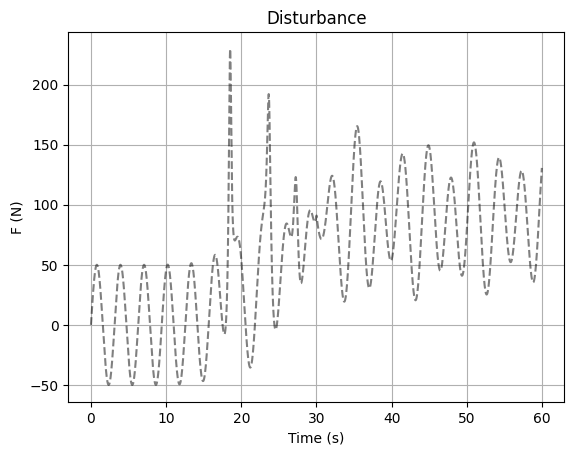

In [11]:
plt.plot(t, hist_time_varying_slow['d'], 'k--', alpha=0.5)
plt.title('Disturbance')
plt.ylabel('F (N)')
plt.xlabel('Time (s)')
plt.grid()

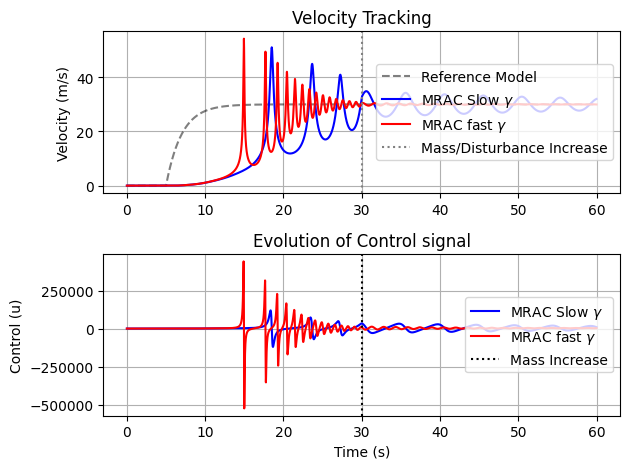

In [12]:
plt.subplot(2, 1, 1)
plt.plot(t, hist_time_varying_slow['vm'], 'k--', label='Reference Model', alpha=0.5)
plt.plot(t, hist_time_varying_slow['v'], 'b', label='MRAC Slow $\gamma$')
plt.plot(t, hist_time_varying_fast['v'], 'r', label='MRAC fast $\gamma$')
plt.axvline(x=disturbance_time, color='gray', linestyle=':', label='Mass/Disturbance Increase')
plt.title('Velocity Tracking')
plt.ylabel('Velocity (m/s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t, hist_time_varying_slow['u'], 'b', label='MRAC Slow $\gamma$')
plt.plot(t, hist_time_varying_fast['u'], 'r', label='MRAC fast $\gamma$')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title('Evolution of Control signal')
plt.ylabel('Control (u)')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.tight_layout()
plt.show()

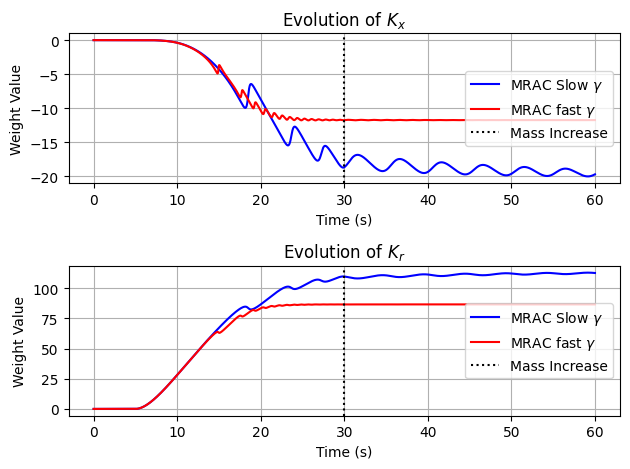

In [13]:
plt.subplot(2, 1, 1)
plt.plot(t, hist_time_varying_slow['Kx'], 'b', label='MRAC Slow $\gamma$')
plt.plot(t, hist_time_varying_fast['Kx'], 'r', label='MRAC fast $\gamma$')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title('Evolution of $K_x$')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t, hist_time_varying_slow['Kr'], 'b', label='MRAC Slow $\gamma$')
plt.plot(t, hist_time_varying_fast['Kr'], 'r', label='MRAC fast $\gamma$')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title('Evolution of $K_r$')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.tight_layout()
plt.show()

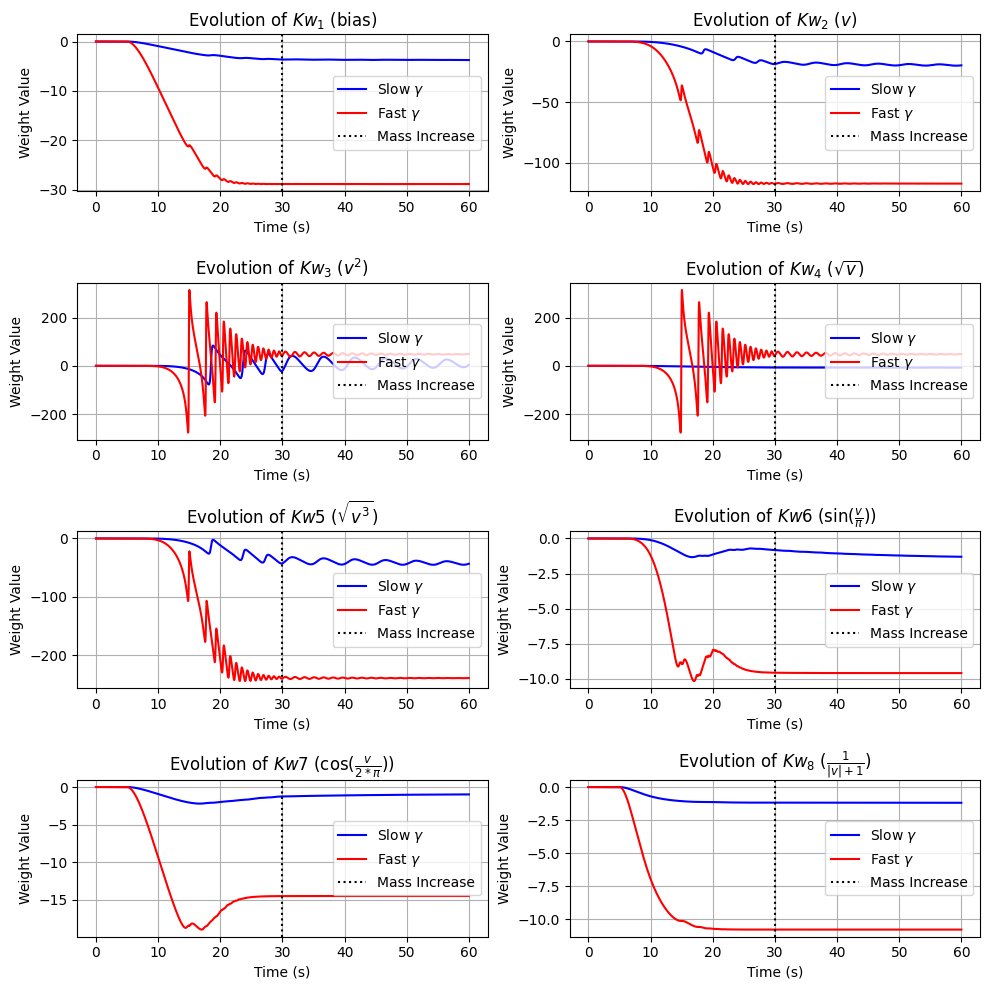

In [14]:
plt.figure(figsize=(10, 10))

plt.subplot(4, 2, 1)
plt.plot(t, hist_time_varying_slow['Kw1'], 'b', label='Slow $\gamma$')
plt.plot(t, hist_time_varying_fast['Kw1'], 'r', label='Fast $\gamma$')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title(r'Evolution of $Kw_1$ (bias)')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(4, 2, 2)
plt.plot(t, hist_time_varying_slow['Kw2'], 'b', label='Slow $\gamma$')
plt.plot(t, hist_time_varying_fast['Kw2'], 'r', label='Fast $\gamma$')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title(r'Evolution of $Kw_2$ ($v$)')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(4, 2, 3)
plt.plot(t, hist_time_varying_slow['Kw3'], 'b', label='Slow $\gamma$')
plt.plot(t, hist_time_varying_fast['Kw3'], 'r', label='Fast $\gamma$')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title(r'Evolution of $Kw_3$ ($v^2$)')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(4, 2, 4)
plt.plot(t, hist_time_varying_slow['Kw4'], 'b', label='Slow $\gamma$')
plt.plot(t, hist_time_varying_fast['Kw3'], 'r', label='Fast $\gamma$')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title(r'Evolution of $Kw_4$ ($\sqrt{v}$)')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(4, 2, 5)
plt.plot(t, hist_time_varying_slow['Kw5'], 'b', label='Slow $\gamma$')
plt.plot(t, hist_time_varying_fast['Kw5'], 'r', label='Fast $\gamma$')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title(r'Evolution of $Kw5$ ($\sqrt{v^3}$)')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(4, 2, 6)
plt.plot(t, hist_time_varying_slow['Kw6'], 'b', label='Slow $\gamma$')
plt.plot(t, hist_time_varying_fast['Kw6'], 'r', label='Fast $\gamma$')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title(r'Evolution of $Kw6$ ($\sin(\frac{v}{\pi})$)')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(4, 2, 7)
plt.plot(t, hist_time_varying_slow['Kw7'], 'b', label='Slow $\gamma$')
plt.plot(t, hist_time_varying_fast['Kw7'], 'r', label='Fast $\gamma$')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title(r'Evolution of $Kw7$ ($\cos(\frac{v}{2*\pi})$)')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.subplot(4, 2, 8)
plt.plot(t, hist_time_varying_slow['Kw8'], 'b', label='Slow $\gamma$')
plt.plot(t, hist_time_varying_fast['Kw8'], 'r', label='Fast $\gamma$')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title(r'Evolution of $Kw_8$ ($\frac{1}{|v|+1}$)')
plt.ylabel('Weight Value')
plt.xlabel('Time (s)')
plt.legend(loc=7)
plt.grid()

plt.tight_layout()
plt.show()

In [15]:
%matplotlib widget
from ipywidgets import interact, FloatSlider
import matplotlib.pyplot as plt

def update(gamma_Kr=0.01, gamma_Kx=0.01, gamma_Kw=0.01):

    plt.close('all')  # prevent memory leak
    
    gamma = [gamma_Kr, gamma_Kx, gamma_Kw]
    
    t, hist = run_simulation_phi(Phi_time_varying, gamma, f_time_varying)

    fig = plt.figure(figsize=(6, 6))

    # === Velocity ===
    ax1 = plt.subplot(4, 1, 1)
    ax1.plot(t, hist['vm'], 'k--', label='Reference', alpha=0.5)
    ax1.plot(t, hist['v'], 'r', label='MRAC')
    ax1.set_title('Velocity Tracking')
    ax1.legend()
    ax1.grid()

    # === Control ===
    ax2 = plt.subplot(4, 1, 2)
    ax2.plot(t, hist['u'], 'b', label='Control')
    ax2.set_title('Control Signal')
    ax2.legend()
    ax2.grid()

    # === Gains ===
    ax3 = plt.subplot(4, 1, 3)
    ax3.plot(t, hist['Kx'], label='Kx')
    ax3.plot(t, hist['Kr'], label='Kr')
    ax3.set_title('Adaptive Gains')
    ax3.legend()
    ax3.grid()
    
    for i in range(2):
        ax = plt.subplot(4, 2, 3*2+i+1)
        ax.plot(t, hist[f'Kw{i+1}'])
        ax.set_title(f'Kw{i+1}')
        ax.grid()

    plt.tight_layout()
    plt.show()

In [16]:
interact(
    update,
    gamma_Kr=FloatSlider(value=0.01, min=0.0, max=5.0, step=0.01),
    gamma_Kx=FloatSlider(value=0.01, min=0.0, max=5.0, step=0.01),
    gamma_Kw=FloatSlider(value=0.01, min=0.0, max=5.0, step=0.01),
);

interactive(children=(FloatSlider(value=0.01, description='gamma_Kr', max=5.0, step=0.01), FloatSlider(value=0…